In [2]:
import pandas
import matplotlib.pyplot
from cycler import cycler

In [3]:
PREDICTION_LENGTH = 10

def read_context_log_as_data_frame(file_path : str) -> pandas.DataFrame:
    columns = [ 'timestamp', 'cache-misses', 'cpu-cycles', 'ref-cycles', 'instructions', 'rx_bytes', 'rx_packets', 'tx_bytes', 'tx_packets', 'item_id', 'p99_latency_ms' ]
    data_frame = pandas.read_csv(file_path, header=None, names=columns, skiprows=1)
    data_frame['timestamp'] = pandas.to_datetime(data_frame['timestamp'])
    return data_frame.set_index('timestamp').sort_index()

def read_prediction_log_as_data_frame(file_path : str) -> pandas.DataFrame:
    columns = [ 'item_id', 'timestamp', 'target_name', 'predictions', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9' ]
    data_frame = pandas.read_csv(file_path, header=None, names=columns)
    data_frame['timestamp'] = pandas.to_datetime(data_frame['timestamp'])
    return data_frame

def read_rps_changes_log_as_series(file_path : str) -> pandas.Series:
    return pandas.to_datetime(pandas.read_csv(file_path, header=None, names=['timestamp'])['timestamp'])

/tmp/ipykernel_58632/391332056.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  raxis.legend(loc="upper right")


Text(0.5, 0, 'Time')

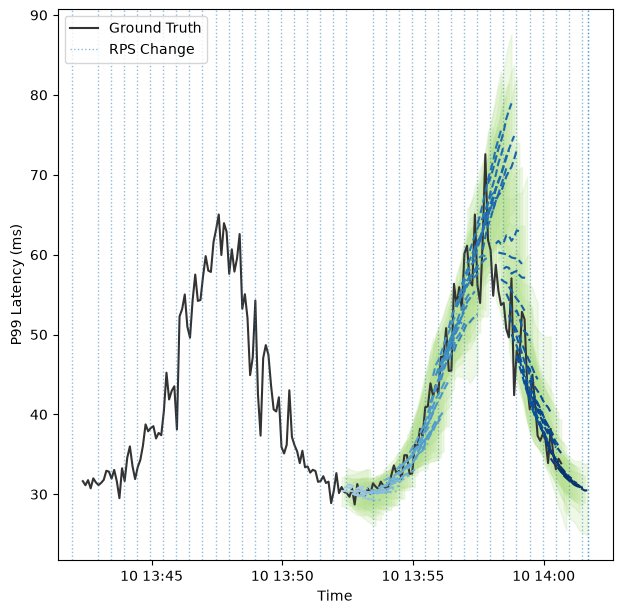

In [ ]:
context_data_frame    = read_context_log_as_data_frame("results/context.log")
prediction_data_frame = read_prediction_log_as_data_frame("results/prediction.log")
rps_changes           = read_rps_changes_log_as_series("results/rps_changes.log")

chunks = [prediction_data_frame.iloc[i:i+PREDICTION_LENGTH] for i in range(0, len(prediction_data_frame), PREDICTION_LENGTH)]

figure, laxis = matplotlib.pyplot.subplots(figsize=(7.16, 7.16))
#raxis = laxis.twinx()

laxis.plot(context_data_frame['p99_latency_ms'], color="#333333", label="Ground Truth")

#raxis.plot(context_data_frame['instructions'] / 1e3, label="Kinstructions")
#raxis.plot(context_data_frame['rx_bytes'], label="rx_bytes")
#raxis.plot(context_data_frame['tx_bytes'], label="tx_bytes")
#raxis.plot(context_data_frame['cpu-cycles'] / 1e3, label="Kcpu-cycles")
#raxis.plot(context_data_frame['ref-cycles'] / 1e3, label="Kref-cycles")
#raxis.plot(context_data_frame['cache-misses'], label='cache-misses')

colormap  = matplotlib.pyplot.get_cmap("Blues")
normalize = matplotlib.colors.Normalize(vmin=0, vmax=len(chunks) - 1)

for chunk_index, chunk in enumerate(chunks):
    laxis.plot(chunk['timestamp'], chunk['predictions'], color=colormap(0.35 + 0.65 * normalize(chunk_index)), linewidth=1.5, linestyle='--')
    laxis.fill_between(chunk["timestamp"], chunk['0.1'], chunk['0.9'], color="#b2df8a", alpha=0.2)

for change_index, timestamp in enumerate(rps_changes):
    laxis.axvline(timestamp, linestyle=":", linewidth=1, alpha=0.5, label="RPS Change" if change_index == 0 else None)

laxis.legend(loc="upper left")
raxis.legend(loc="upper right")

#laxis.set_title("Real Time P99 Latency Predictions Using eBPF Probe Data as Covariates")
laxis.set_ylabel("P99 Latency (ms)")
#laxis.set_xlabel("Time")
#raxis.set_ylabel("P99 Latency (ms)")